In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

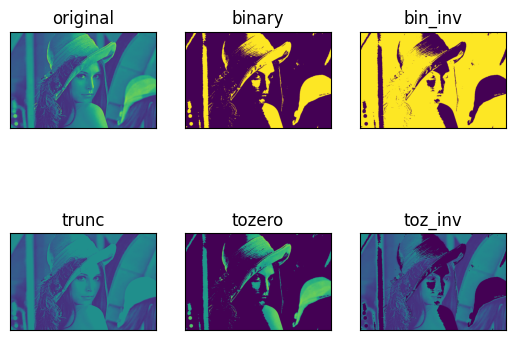

In [5]:
# 1
img = cv2.imread('/content/img_lenna.jpg', cv2.IMREAD_GRAYSCALE)

ret, t1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
ret, t2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
ret, t3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
ret, t4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
ret, t5 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)

titles = ['original', 'binary', 'bin_inv', 'trunc', 'tozero', 'toz_inv']
imgs = [img, t1, t2, t3, t4, t5]

for i in range(6):
  plt.subplot(2, 3, i+1)
  plt.title(titles[i])
  plt.imshow(imgs[i], vmin=0, vmax=255)
  plt.xticks([])
  plt.yticks([])
plt.show()

In [8]:
# 2
image = cv2.imread('/content/1.jpg')
image.shape

(900, 600, 3)

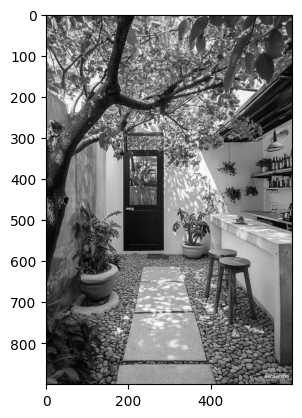

In [10]:
img_gray = 0.3*image[:,:,0] + 0.6*image[:,:,1] + 0.11*image[:,:,2]
plt.imshow(img_gray, cmap='gray')

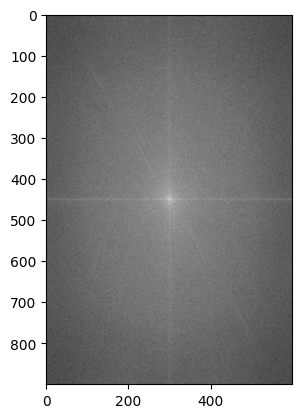

In [25]:
ft = np.fft.fft2(img_gray)
dft_shift = np.fft.fftshift(ft)
plt.imshow(np.log(np.abs(dft_shift)), cmap='gray')


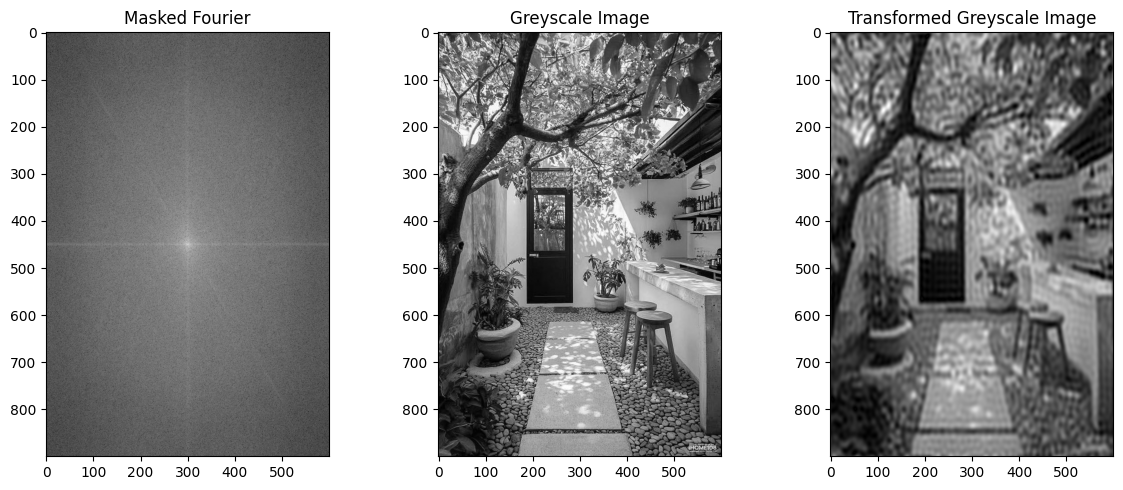

In [28]:

img = cv2.imread('/content/1.jpg', cv2.IMREAD_GRAYSCALE)

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2, cols//2
mask = np.zeros((rows, cols), np.uint8)
r = 50   # bán kính giữ lại
cv2.circle(mask, (ccol, crow), r, 1, -1)

fshift_masked = fshift * mask

f_ishift = np.fft.ifftshift(fshift_masked)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(np.log(np.abs(fshift)), cmap='gray')
plt.title("Masked Fourier")
plt.subplot(1,3,2)
plt.imshow(img, cmap='gray')
plt.title("Greyscale Image")
plt.subplot(1,3,3)
plt.imshow(img_back, cmap='gray')
plt.title("Transformed Greyscale Image")

plt.tight_layout()
plt.show()

# tham khảo: https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_transforms/py_fourier_transform/py_fourier_transform.html

In [51]:
class ImageTransform:
    def __init__(self, image_path):
        # Khởi tạo và đọc ảnh
        self.image = cv2.imread(image_path)
        self.image = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
    def cal_hist(self):
        color = ('r', 'g', 'b')
        plt.figure()
        for i, col in enumerate(color):
            hist = cv2.calcHist([self.image], [i], None, [256], [0, 256])
            plt.plot(hist, color=col)
        plt.show()

    def img_3_3(self):
        h, w, c = self.image.shape
        new = np.zeros((h*2, w*2, c), dtype=np.uint8)
        new[0:h, w:2*w] = self.image
        return new

    def cal_grad(self):
        gray = cv2.cvtColor(self.image, cv2.COLOR_RGB2GRAY)
        gX = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gY = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        grad = cv2.magnitude(gX, gY)
        grad = cv2.convertScaleAbs(grad)
        return grad

    def scaled_img(self):
        h, w = self.image.shape[:2]
        new = cv2.resize(self.image, (w//2, h//2))
        return new

    def rotated_img(self):
        h, w = self.image.shape[:2]
        M = cv2.getRotationMatrix2D((0, h), 45, 1.2)
        new = cv2.warpAffine(self.image, M, (int(w*1.5), int(h*1.5)))
        return new

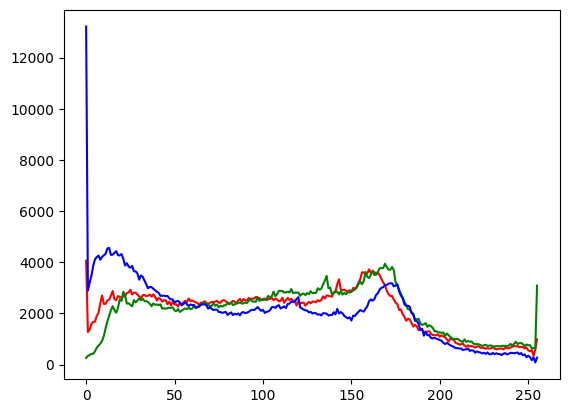

array([[  0, 126, 255, ..., 202,  44,   0],
       [ 30, 144, 255, ..., 203,  83,  86],
       [126, 153, 171, ...,  62, 108, 110],
       ...,
       [ 24,  63,  46, ..., 116, 255, 160],
       [  4,  39,  33, ..., 255, 255, 132],
       [  0,  26,  22, ..., 188, 255,   0]], dtype=uint8)
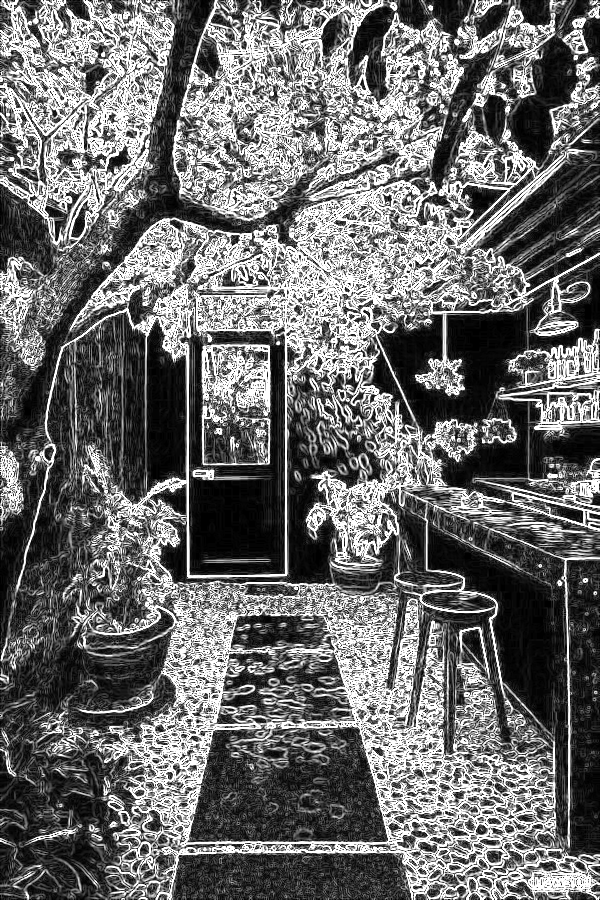

In [57]:
# sử dụng class
test = ImageTransform('/content/1.jpg')
test.cal_hist()
test.img_3_3()
test.cal_grad()

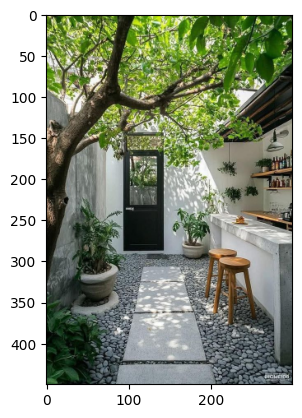

In [61]:
plt.imshow(test.scaled_img())

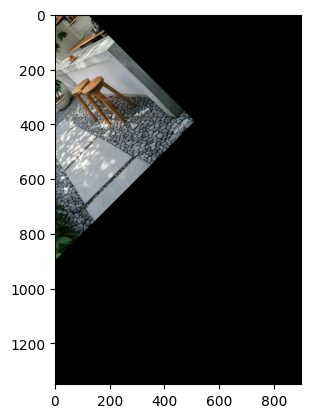

In [60]:
plt.imshow(test.rotated_img())

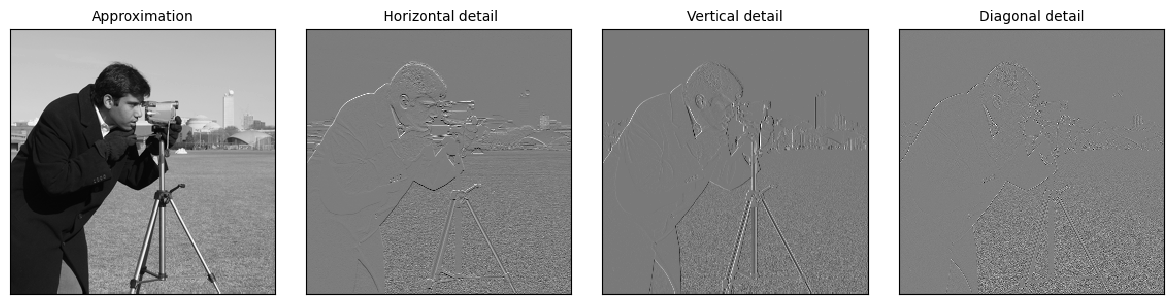

In [62]:
# tham khảo: https://pywavelets.readthedocs.io/en/latest/
import pywt
import pywt.data

original = pywt.data.camera()


titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeffs2 = pywt.dwt2(original, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()
